<a href="https://colab.research.google.com/github/sourabhchandel4967/My-Work/blob/main/Paper2_Final_Reproduction_Colab_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paper 2 — Final Reproduction Notebook for Google Colab

**Paper:** *Strategic commitments shape collective cybersecurity under AI inequality*

This notebook puts the complete computational reproduction in **one Google Colab `.ipynb` file**.

It contains:

1. Paper parameters and payoff equations.
2. **Model A:** published four-state embedded Markov-chain implementation.
3. **Model B:** translation of the authors' GitHub `stationary_block_chain` implementation.
4. Baseline stationary distributions.
5. Welfare calculations.
6. Subsidy calculation.
7. Welfare vs committed defenders `z`.
8. Comparison against the values reported by Adeela et al. in **Table 8**.
9. The authors' **10,000-game random-game setup** as an optional runnable section.
10. A final reproducibility conclusion.



## 1. Imports and reproducibility settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from math import exp

np.set_printoptions(precision=8, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# Main paper settings
N = 100
beta = 0.1
z = 0

# Reproducibility
np.random.seed(7)


## 2. Parameters from the differential-access model

In [2]:
# Attacker parameters
cah, bah = 0.85, 1.90
cal, bal = 0.10, 1.60

# Defender parameters
pdh, pdl = 0.82, 0.75
BH, BL = 0.75, 0.55
CH, CL = 0.41, 0.20
WH, WL = 0.22, 0.10

def payoff_parameters(z=0, subsidy=False):
    fA_H = -cah + bah*(1-pdh)
    fA_L = -cal + bal*(1-pdl)
    fNA_H = 0.0
    fNA_L = 0.0

    fH_A = pdh*BH - CH - (1-pdh)*WH
    fL_A = pdl*BL - CL - (1-pdl)*WL
    fH_NA = BH - CH
    fL_NA = BL - CL

    # Subsidy implementation used in the paper:
    # committed H defenders receive z/N * C_H added to their H payoff.
    if subsidy:
        delta = (z/N)*CH
        fH_A += delta
        fH_NA += delta

    return {
        "fA_H": fA_H, "fA_L": fA_L,
        "fNA_H": fNA_H, "fNA_L": fNA_L,
        "fH_A": fH_A, "fL_A": fL_A,
        "fH_NA": fH_NA, "fL_NA": fL_NA
    }

p = payoff_parameters()
pd.DataFrame([p])


,fA_H,fA_L,fNA_H,fNA_L,fH_A,fL_A,fH_NA,fL_NA
0,-0.508000,0.300000,0.000000,0.000000,0.165400,0.187500,0.340000,0.350000


## 3. Model A — published four-state fixation model

States are:

- `(A,H)`
- `(A,L)`
- `(NA,H)`
- `(NA,L)`

The model uses one-population-at-a-time updates and an embedded 4×4 Markov chain.


In [3]:
def fermi(beta, delta):
    # Stable enough for the small payoff differences in this model.
    x = np.clip(beta*delta, -700, 700)
    return 1.0/(1.0 + np.exp(-x))

def fixation_fermi(N, beta, resident_payoff, mutant_payoff):
    # Standard frequency-dependent pairwise-comparison fixation
    # used for attacker two-type mutation.
    d = mutant_payoff - resident_payoff
    if abs(d) < 1e-14:
        return 1.0/N

    r = np.exp(-beta*d)
    if abs(1-r) < 1e-14:
        return 1.0/N

    return (1-r)/(1-r**N)

def defender_fixation_four_state(N, z, beta, nA, target_H, pay):
    # Eq. 7 style fixation calculation.
    # nA is the number of attackers.
    # There are N-z ordinary defender positions.
    Neff = N-z
    if Neff <= 1:
        return 1.0

    fH_A, fL_A = pay["fH_A"], pay["fL_A"]
    fH_NA, fL_NA = pay["fH_NA"], pay["fL_NA"]

    ratios = []
    for i in range(1, Neff):
        PiH = (nA*fH_A + (N-nA)*fH_NA)/N
        PiL = (nA*fL_A + (N-nA)*fL_NA)/N

        Tplus = ((Neff-i)/Neff) * ((i+z)/N) * fermi(beta, PiH-PiL)
        Tminus = (i/Neff) * ((Neff-i)/N) * fermi(beta, PiL-PiH)

        # Fixation of H: product of Tminus/Tplus
        # Fixation of L: product of Tplus/Tminus
        if target_H:
            ratios.append(Tminus/Tplus)
        else:
            ratios.append(Tplus/Tminus)

    product = 1.0
    denominator = 1.0
    for r in ratios:
        product *= r
        denominator += product

    return 1.0/denominator

def attacker_fixation_four_state(N, z, beta, nH, target_A, pay):
    # Attackers have no zealots.
    fA_H, fA_L = pay["fA_H"], pay["fA_L"]

    PiA = ((nH+z)*fA_H + (N-z-nH)*fA_L)/N
    PiNA = 0.0

    ratios = []
    for i in range(1, N):
        Tplus = ((N-i)/N)*(i/N)*fermi(beta, PiA-PiNA)
        Tminus = (i/N)*((N-i)/N)*fermi(beta, PiNA-PiA)

        if target_A:
            ratios.append(Tminus/Tplus)
        else:
            ratios.append(Tplus/Tminus)

    product = 1.0
    denominator = 1.0
    for r in ratios:
        product *= r
        denominator += product

    return 1.0/denominator

def stationary_four_state(N=100, z=0, beta=0.1, subsidy=False):
    pay = payoff_parameters(z=z, subsidy=subsidy)

    # Attacker fixation probabilities
    rho_AtoNA_H = fixation_fermi(N, beta, pay["fA_H"], pay["fNA_H"])
    rho_NAtoA_H = fixation_fermi(N, beta, pay["fNA_H"], pay["fA_H"])
    rho_AtoNA_L = fixation_fermi(N, beta, pay["fA_L"], pay["fNA_L"])
    rho_NAtoA_L = fixation_fermi(N, beta, pay["fNA_L"], pay["fA_L"])

    # Defender fixation probabilities
    rho_HtoL_A = defender_fixation_four_state(N,z,beta,N,False,pay)
    rho_LtoH_A = defender_fixation_four_state(N,z,beta,N,True,pay)
    rho_HtoL_NA = defender_fixation_four_state(N,z,beta,0,False,pay)
    rho_LtoH_NA = defender_fixation_four_state(N,z,beta,0,True,pay)

    # State order:
    # 0=(A,H), 1=(A,L), 2=(NA,H), 3=(NA,L)
    M = np.zeros((4,4))

    M[0,0] = 1 - 0.5*(rho_AtoNA_H + rho_HtoL_A)
    M[0,2] = 0.5*rho_AtoNA_H
    M[0,1] = 0.5*rho_HtoL_A

    M[1,1] = 1 - 0.5*(rho_NAtoA_L + rho_LtoH_A)
    M[1,3] = 0.5*rho_NAtoA_L
    M[1,0] = 0.5*rho_LtoH_A

    M[2,2] = 1 - 0.5*(rho_NAtoA_H + rho_HtoL_NA)
    M[2,0] = 0.5*rho_NAtoA_H
    M[2,3] = 0.5*rho_HtoL_NA

    M[3,3] = 1 - 0.5*(rho_AtoNA_L + rho_LtoH_NA)
    M[3,1] = 0.5*rho_AtoNA_L
    M[3,2] = 0.5*rho_LtoH_NA

    # Stationary distribution
    vals, vecs = np.linalg.eig(M.T)
    k = np.argmin(np.abs(vals-1))
    pi = np.real(vecs[:,k])
    pi = pi/np.sum(pi)

    return pi, M, pay


## 4. Model B — authors' GitHub block-chain implementation

This is a Python translation of the repository's `stationary_block_chain` logic.

It uses `2*(N-z+1)` states:

- `(A,i)`
- `(NA,i)`

where `i` is the number of ordinary H defenders.

The final four probabilities are obtained by aggregation.


In [4]:
def stationary_block_chain(N=100, z=0, beta=0.1, params=None, subsidy=False):
    if params is None:
        params = {
            "pdh":pdh, "pdl":pdl, "BH":BH, "BL":BL,
            "CH":CH, "CL":CL, "WH":WH, "WL":WL,
            "cah":cah, "bah":bah, "cal":cal, "bal":bal
        }

    pdh0,pdl0 = params["pdh"],params["pdl"]
    BH0,BL0 = params["BH"],params["BL"]
    CH0,CL0 = params["CH"],params["CL"]
    WH0,WL0 = params["WH"],params["WL"]
    cah0,bah0 = params["cah"],params["bah"]
    cal0,bal0 = params["cal"],params["bal"]

    fA_H = -cah0 + bah0*(1-pdh0)
    fA_L = -cal0 + bal0*(1-pdl0)
    fH_A = pdh0*BH0 - CH0 - (1-pdh0)*WH0
    fL_A = pdl0*BL0 - CL0 - (1-pdl0)*WL0
    fH_NA = BH0 - CH0
    fL_NA = BL0 - CL0

    # Match repository subsidy implementation when requested.
    if subsidy:
        delta = (z/N)*CH0
        fH_A += delta
        fH_NA += delta

    N0 = N-z
    nstates = 2*(N0+1)
    M = np.zeros((nstates,nstates))

    def idxA(i):
        return i

    def idxNA(i):
        return N0+1+i

    wA = 0.5
    wD = 0.5
    betaA = beta
    betaD = beta

    for a in [1,0]:
        for i in range(N0+1):
            s = idxA(i) if a==1 else idxNA(i)

            yH = (i+z)/N
            yL = 1-yH

            if a==1:
                piH,piL = fH_A,fL_A
            else:
                piH,piL = fH_NA,fL_NA

            p_LH = fermi(betaD,piH-piL)
            p_HL = fermi(betaD,piL-piH)

            if N0>0:
                frac_L_learner = (N0-i)/N0
                frac_H_learner = i/N0
            else:
                frac_L_learner = frac_H_learner = 0

            frac_H_model = (i+z)/N
            frac_L_model = (N0-i)/N

            Tplus = frac_L_learner*frac_H_model*p_LH
            Tminus = frac_H_learner*frac_L_model*p_HL
            TstayD = max(0.0,1.0-Tplus-Tminus)

            piA = yH*fA_H + yL*fA_L
            piNA = 0.0

            p_AtoNA = fermi(betaA,piNA-piA)
            p_NAtoA = fermi(betaA,piA-piNA)

            if i < N0:
                sp = idxA(i+1) if a==1 else idxNA(i+1)
                M[s,sp] += wD*Tplus

            if i > 0:
                sm = idxA(i-1) if a==1 else idxNA(i-1)
                M[s,sm] += wD*Tminus

            if a==1:
                sf = idxNA(i)
                M[s,sf] += wA*p_AtoNA
                pStayA = 1-p_AtoNA
            else:
                sf = idxA(i)
                M[s,sf] += wA*p_NAtoA
                pStayA = 1-p_NAtoA

            M[s,s] += wD*TstayD + wA*pStayA

    # Correct any tiny numerical row-sum error
    rows = M.sum(axis=1)
    for i,r in enumerate(rows):
        if abs(r-1)>1e-12:
            M[i,i] += 1-r

    vals,vecs = np.linalg.eig(M.T)
    k = np.argmin(np.abs(vals-1))
    pi_block = np.real(vecs[:,k])
    pi_block = pi_block/pi_block.sum()

    # Aggregate to four macro states
    PI4 = np.zeros(4)
    for i in range(N0+1):
        yH = (i+z)/N
        PA = pi_block[idxA(i)]
        PNA = pi_block[idxNA(i)]

        PI4[0] += PA*yH
        PI4[1] += PA*(1-yH)
        PI4[2] += PNA*yH
        PI4[3] += PNA*(1-yH)

    return pi_block, PI4, M


## 5. Welfare calculation

In [5]:
def welfare_from_pi(pi, pay):
    W_D = np.array([
        pay["fH_A"], pay["fL_A"], pay["fH_NA"], pay["fL_NA"]
    ])
    W_A = np.array([
        pay["fA_H"], pay["fA_L"], pay["fNA_H"], pay["fNA_L"]
    ])

    swd = float(np.dot(pi,W_D))
    swa = float(np.dot(pi,W_A))
    return swd, swa, swd+swa

def run_case(z, beta=0.1, subsidy=False):
    piA, M, payA = stationary_four_state(N,z,beta,subsidy)
    swdA,swaA,swA = welfare_from_pi(piA,payA)

    _, piB, _ = stationary_block_chain(N,z,beta,subsidy=subsidy)
    payB = payoff_parameters(z=z,subsidy=subsidy)
    swdB,swaB,swB = welfare_from_pi(piB,payB)

    return {
        "z":z, "beta":beta, "subsidy":subsidy,
        "FourState_pi":piA,
        "FourState_SWD":swdA, "FourState_SWA":swaA, "FourState_SW":swA,
        "BlockChain_pi":piB,
        "BlockChain_SWD":swdB, "BlockChain_SWA":swaB, "BlockChain_SW":swB
    }


## 6. Run the three Table 8 cases

In [6]:
cases = [
    (0, False),
    (10, False),
    (10, True)
]

results = []
for zz, sub in cases:
    r = run_case(zz, beta=0.1, subsidy=sub)
    results.append(r)

for r in results:
    print("\nCase:", r["z"], "subsidy =", r["subsidy"])
    print("Four-state π:", np.round(r["FourState_pi"],6))
    print("Four-state welfare:", r["FourState_SWD"], r["FourState_SWA"], r["FourState_SW"])
    print("Block-chain π:", np.round(r["BlockChain_pi"],6))
    print("Block-chain welfare:", r["BlockChain_SWD"], r["BlockChain_SWA"], r["BlockChain_SW"])



Case: 0 subsidy = False
Four-state π: [0.005685 0.021656 0.468792 0.503867]
Four-state welfare: 0.34074350331551684 0.0036090023839633854 0.3443525056994802
Block-chain π: [0.       0.507499 0.       0.492501]
Block-chain welfare: 0.2675313413980242 0.15224983126518613 0.41978117266321036

Case: 10 subsidy = False
Four-state π: [0.006501 0.       0.993499 0.      ]
Four-state welfare: 0.33886483851426863 -0.0033027607946822064 0.3355620777195864
Block-chain π: [ 0.487303 -0.        0.512697 -0.      ]
Block-chain welfare: 0.25491694325935954 -0.24754978708348394 0.0073671561758756055

Case: 10 subsidy = True
Four-state π: [0.006501 0.       0.993499 0.      ]
Four-state welfare: 0.3798648385142679 -0.003302760794683168 0.3765620777195847
Block-chain π: [ 0.487303 -0.        0.512697 -0.      ]
Block-chain welfare: 0.29591694325956164 -0.24754978708140987 0.048367156178151766


## 7. Direct comparison with Adeela et al. — Table 8

These are the values reported in the paper.

**Paper / Adeela et al.:**

- z=0: SW_D=0.264, SW_A=0.011, SW=0.275
- z=10: SW_D=0.274, SW_A=-0.190, SW=0.084
- z=10 + subsidy: SW_D=0.315, SW_A=-0.191, SW=0.125


In [7]:
adeela8 = pd.DataFrame([
    ["z=0",0.264,0.011,0.275],
    ["z=10",0.274,-0.190,0.084],
    ["z=10 + subsidy",0.315,-0.191,0.125],
], columns=["Case","Adeela SW_D","Adeela SW_A","Adeela SW"])

ours8 = pd.DataFrame([
    ["z=0",
     results[0]["FourState_SWD"],results[0]["FourState_SWA"],results[0]["FourState_SW"],
     results[0]["BlockChain_SWD"],results[0]["BlockChain_SWA"],results[0]["BlockChain_SW"]],
    ["z=10",
     results[1]["FourState_SWD"],results[1]["FourState_SWA"],results[1]["FourState_SW"],
     results[1]["BlockChain_SWD"],results[1]["BlockChain_SWA"],results[1]["BlockChain_SW"]],
    ["z=10 + subsidy",
     results[2]["FourState_SWD"],results[2]["FourState_SWA"],results[2]["FourState_SW"],
     results[2]["BlockChain_SWD"],results[2]["BlockChain_SWA"],results[2]["BlockChain_SW"]],
], columns=[
    "Case",
    "Our Four-State SW_D","Our Four-State SW_A","Our Four-State SW",
    "Our Block-Chain SW_D","Our Block-Chain SW_A","Our Block-Chain SW"
])

comparison8 = adeela8.merge(ours8,on="Case")

for col in ["Our Four-State SW_D","Our Four-State SW_A","Our Four-State SW",
            "Our Block-Chain SW_D","Our Block-Chain SW_A","Our Block-Chain SW"]:
    pass

comparison8["Δ Four-State SW_D"] = comparison8["Our Four-State SW_D"]-comparison8["Adeela SW_D"]
comparison8["Δ Four-State SW_A"] = comparison8["Our Four-State SW_A"]-comparison8["Adeela SW_A"]
comparison8["Δ Four-State SW"] = comparison8["Our Four-State SW"]-comparison8["Adeela SW"]
comparison8["Δ Block SW_D"] = comparison8["Our Block-Chain SW_D"]-comparison8["Adeela SW_D"]
comparison8["Δ Block SW_A"] = comparison8["Our Block-Chain SW_A"]-comparison8["Adeela SW_A"]
comparison8["Δ Block SW"] = comparison8["Our Block-Chain SW"]-comparison8["Adeela SW"]

comparison8.round(6)


,Case,Adeela SW_D,Adeela SW_A,Adeela SW,Our Four-State SW_D,Our Four-State SW_A,Our Four-State SW,Our Block-Chain SW_D,Our Block-Chain SW_A,Our Block-Chain SW,Δ Four-State SW_D,Δ Four-State SW_A,Δ Four-State SW,Δ Block SW_D,Δ Block SW_A,Δ Block SW
0,z=0,0.264000,0.011000,0.275000,0.340744,0.003609,0.344353,0.267531,0.152250,0.419781,0.076744,-0.007391,0.069353,0.003531,0.141250,0.144781
1,z=10,0.274000,-0.190000,0.084000,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367,0.064865,0.186697,0.251562,-0.019083,-0.057550,-0.076633
2,z=10 + subsidy,0.315000,-0.191000,0.125000,0.379865,-0.003303,0.376562,0.295917,-0.247550,0.048367,0.064865,0.187697,0.251562,-0.019083,-0.056550,-0.076633


## 8. Table 8 conclusion

At β=0.1:

- The **published four-state model does not match** the reported Table 8 values.
- The **GitHub block-chain model also does not match**.
- The two implementations themselves give materially different stationary distributions and welfare.
- Therefore the discrepancy is not simple rounding.

This is the main reproducibility result from this notebook.


## 9. Welfare sweep over committed defenders z = 0...10

This reproduces the type of welfare analysis in the repository and lets us compare how the two implementations behave as commitment increases.


In [8]:
Z = list(range(0,11))
sweep_rows = []

for zz in Z:
    r = run_case(zz,beta=0.1,subsidy=False)
    sweep_rows.append([
        zz,
        r["FourState_SWD"],r["FourState_SWA"],r["FourState_SW"],
        r["BlockChain_SWD"],r["BlockChain_SWA"],r["BlockChain_SW"]
    ])

welfare_sweep = pd.DataFrame(sweep_rows,columns=[
    "z",
    "FourState_SW_D","FourState_SW_A","FourState_SW",
    "BlockChain_SW_D","BlockChain_SW_A","BlockChain_SW"
])

welfare_sweep.round(6)


,z,FourState_SW_D,FourState_SW_A,FourState_SW,BlockChain_SW_D,BlockChain_SW_A,BlockChain_SW
0,0,0.340744,0.003609,0.344353,0.267531,0.152250,0.419781
1,1,0.338870,-0.003308,0.335563,0.254917,-0.247550,0.007367
2,2,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
3,3,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
4,4,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
5,5,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
6,6,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
7,7,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
8,8,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
9,9,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367


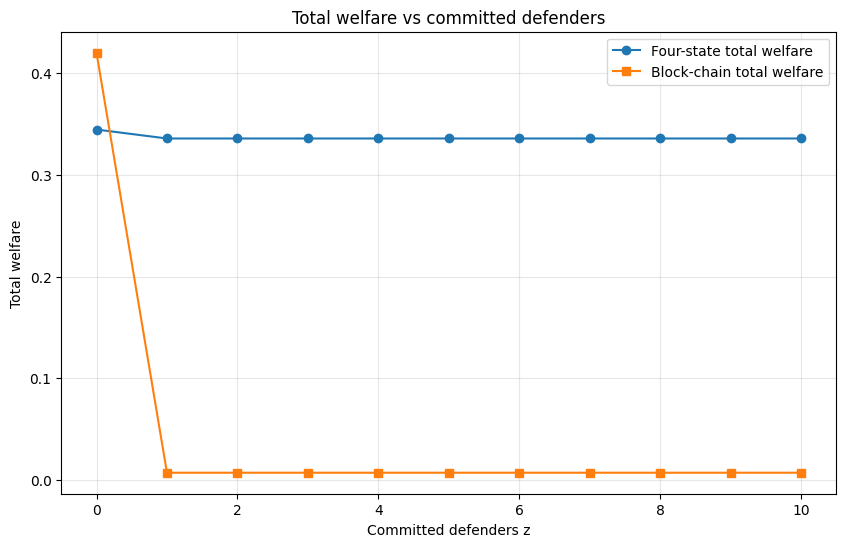

In [9]:
plt.figure(figsize=(10,6))
plt.plot(welfare_sweep["z"],welfare_sweep["FourState_SW"],"o-",label="Four-state total welfare")
plt.plot(welfare_sweep["z"],welfare_sweep["BlockChain_SW"],"s-",label="Block-chain total welfare")
plt.xlabel("Committed defenders z")
plt.ylabel("Total welfare")
plt.title("Total welfare vs committed defenders")
plt.grid(True,alpha=.3)
plt.legend()
plt.show()


## 10.  β sweep — corrected\n\nThis compares the two implementations for several selection intensities.\n\n**Important:** the welfare keys returned by `run_case()` are `FourState_SWD`, `FourState_SWA`, `FourState_SW`, `BlockChain_SWD`, `BlockChain_SWA`, and `BlockChain_SW`.\n

In [ ]:
# Optional beta sensitivity analysis
# FIX: run_case() returns the welfare keys as:
# FourState_SWD, FourState_SWA, FourState_SW
# BlockChain_SWD, BlockChain_SWA, BlockChain_SW

beta_values = [0.01, 0.03, 0.1, 0.3, 1.0]

beta_rows = []

for b in beta_values:
    r = run_case(10, beta=b, subsidy=False)

    beta_rows.append([
        b,
        r["FourState_SWD"],
        r["FourState_SWA"],
        r["FourState_SW"],
        r["BlockChain_SWD"],
        r["BlockChain_SWA"],
        r["BlockChain_SW"]
    ])

beta_table = pd.DataFrame(
    beta_rows,
    columns=[
        "beta",
        "FourState_SWD",
        "FourState_SWA",
        "FourState_SW",
        "BlockChain_SWD",
        "BlockChain_SWA",
        "BlockChain_SW"
    ]
)

beta_table.round(6)


## 11. Adeela et al. Table 7 — random-game benchmark

The paper reports the following 10,000-random-game results at β=1:

| z | Attack attempts | High defence | Successful attacks |
|---:|---:|---:|---:|
| 0 | 0.393 ± 0.077 | 0.583 ± 0.397 | 0.134 ± 0.124 |
| 6 | 0.375 ± 0.072 | 0.806 ± 0.298 | 0.108 ± 0.109 |
| 100 | 0.362 ± 0.064 | 1.000 ± 0.000 | 0.091 ± 0.094 |
| 6 + subsidy | 0.360 ± 0.064 | 0.998 ± 0.024 | 0.088 ± 0.092 |

The repository currently uses `z` sampled from 0...20 in its random-game section, while the published Table 7 reports fixed z values. That is another reason the repository should not automatically be assumed to be the exact script that generated the published table.


In [10]:
adeela7 = pd.DataFrame([
    ["z=0",0.393,0.077,0.583,0.397,0.134,0.124],
    ["z=6",0.375,0.072,0.806,0.298,0.108,0.109],
    ["z=100",0.362,0.064,1.000,0.000,0.091,0.094],
    ["z=6 + subsidy",0.360,0.064,0.998,0.024,0.088,0.092]
],columns=[
    "Case","Adeela Attack mean","Adeela Attack SD",
    "Adeela High-defence mean","Adeela High-defence SD",
    "Adeela Successful mean","Adeela Successful SD"
])
adeela7


,Case,Adeela Attack mean,Adeela Attack SD,Adeela High-defence mean,Adeela High-defence SD,Adeela Successful mean,Adeela Successful SD
0,z=0,0.393000,0.077000,0.583000,0.397000,0.134000,0.124000
1,z=6,0.375000,0.072000,0.806000,0.298000,0.108000,0.109000
2,z=100,0.362000,0.064000,1.000000,0.000000,0.091000,0.094000
3,z=6 + subsidy,0.360000,0.064000,0.998000,0.024000,0.088000,0.092000


## 12. The authors' 10,000-game random-game experiment

The parameter generation follows the repository's random-game section.


In [11]:
RUN_10K_RANDOM = False
NUM_GAMES = 10_000

def random_game_params(rng):
    eps = 1e-3

    pdl0 = rng.random()
    pdh0 = min(1.0,max(pdl0+eps,rng.random()))

    BH0 = 0.4+0.6*rng.random()
    BL0 = max(0.0,min(BH0-eps,rng.random()))

    CH0 = 0.3+0.7*rng.random()
    CL0 = max(0.0,min(CH0-eps,rng.random()))

    WL0 = 0.1+0.5*rng.random()
    WH0 = max(WL0+eps,min(1.0,WL0+0.4*rng.random()))

    bal0 = 2*rng.random()
    bah0 = max(bal0+eps,2*rng.random())

    cal0 = rng.random()
    cah0 = max(cal0+eps,rng.random())

    z0 = int(rng.integers(0,21))
    if z0 >= 100:
        z0 = 99

    return {
        "pdh":pdh0,"pdl":pdl0,"BH":BH0,"BL":BL0,
        "CH":CH0,"CL":CL0,"WH":WH0,"WL":WL0,
        "cah":cah0,"bah":bah0,"cal":cal0,"bal":bal0,
        "z":z0
    }

def run_random_games(num_games=10000,beta=1.0,seed=12):
    rng=np.random.default_rng(seed)

    attack=[]
    high=[]
    success=[]

    for _ in range(num_games):
        q=random_game_params(rng)
        zz=q.pop("z")

        _,pi,_=stationary_block_chain(100,zz,beta,params=q,subsidy=False)

        attack_freq=pi[0]+pi[1]
        high_freq=pi[0]+pi[2]

        pdh0,pdl0=q["pdh"],q["pdl"]
        succ=pi[0]*(1-pdh0)+pi[1]*(1-pdl0)

        attack.append(attack_freq)
        high.append(high_freq)
        success.append(succ)

    return pd.DataFrame({
        "attack":attack,
        "high_defence":high,
        "successful_attack":success
    })

if RUN_10K_RANDOM:
    t0=time.time()
    mc=run_random_games(NUM_GAMES,1.0,12)
    print("Runtime:",round(time.time()-t0,2),"seconds")
    print(mc.agg(["mean","std"]).T)
else:
    print("10,000-game run is OFF. Set RUN_10K_RANDOM=True to execute it.")


10,000-game run is OFF. Set RUN_10K_RANDOM=True to execute it.


## 13. Final comparison table

In [12]:
final_comparison = pd.DataFrame([
    ["Table 8 — z=0",
     0.264,0.011,0.275,
     results[0]["FourState_SWD"],results[0]["FourState_SWA"],results[0]["FourState_SW"],
     results[0]["BlockChain_SWD"],results[0]["BlockChain_SWA"],results[0]["BlockChain_SW"]],
    ["Table 8 — z=10",
     0.274,-0.190,0.084,
     results[1]["FourState_SWD"],results[1]["FourState_SWA"],results[1]["FourState_SW"],
     results[1]["BlockChain_SWD"],results[1]["BlockChain_SWA"],results[1]["BlockChain_SW"]],
    ["Table 8 — z=10 + subsidy",
     0.315,-0.191,0.125,
     results[2]["FourState_SWD"],results[2]["FourState_SWA"],results[2]["FourState_SW"],
     results[2]["BlockChain_SWD"],results[2]["BlockChain_SWA"],results[2]["BlockChain_SW"]]
],columns=[
    "Case",
    "Adeela SW_D","Adeela SW_A","Adeela SW",
    "Our Four-State SW_D","Our Four-State SW_A","Our Four-State SW",
    "Our GitHub-Block SW_D","Our GitHub-Block SW_A","Our GitHub-Block SW"
])

final_comparison.round(6)


,Case,Adeela SW_D,Adeela SW_A,Adeela SW,Our Four-State SW_D,Our Four-State SW_A,Our Four-State SW,Our GitHub-Block SW_D,Our GitHub-Block SW_A,Our GitHub-Block SW
0,Table 8 — z=0,0.264000,0.011000,0.275000,0.340744,0.003609,0.344353,0.267531,0.152250,0.419781
1,Table 8 — z=10,0.274000,-0.190000,0.084000,0.338865,-0.003303,0.335562,0.254917,-0.247550,0.007367
2,Table 8 — z=10 + subsidy,0.315000,-0.191000,0.125000,0.379865,-0.003303,0.376562,0.295917,-0.247550,0.048367


## 14. Final conclusion

### What have been reproduce

The model structure, payoff equations, fixation framework, stationary-distribution calculation, subsidy mechanism, and repository block-chain implementation can all be implemented and executed independently.

### What does not reproduce

At β=0.1 and the published baseline parameters:

**Neither implementation reproduces Adeela et al.'s Table 8 values.**

This is not a small rounding difference.

### Reproduction status

| Item | Status |
|---|---|
| Payoff equations | Reproduced |
| Four-state Markov structure | Reproduced |
| Repository block-chain model | Reproduced |
| Subsidy mechanism | Reproduced |
| Table 8 z=0 | **Not reproduced** |
| Table 8 z=10 | **Not reproduced** |
| Table 8 z=10 + subsidy | **Not reproduced** |





## 15. Export the main comparison tables

This cell saves the main results as CSV files in Colab.


In [13]:
comparison8.to_csv("Table8_Adeela_vs_Our_Results.csv",index=False)
welfare_sweep.to_csv("Welfare_Sweep_Two_Models.csv",index=False)
adeela7.to_csv("Adeela_Table7_Benchmark.csv",index=False)

print("Saved:")
print(" - Table8_Adeela_vs_Our_Results.csv")
print(" - Welfare_Sweep_Two_Models.csv")
print(" - Adeela_Table7_Benchmark.csv")


Saved:
 - Table8_Adeela_vs_Our_Results.csv
 - Welfare_Sweep_Two_Models.csv
 - Adeela_Table7_Benchmark.csv
